In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

In [4]:
# Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names

In [35]:
X = df[["sepal_length", "sepal_width", "petal_length", "petal_width"]]
y = df[["species"]]
print(X)
print(y)

     sepal_length  sepal_width  petal_length  petal_width
0             5.1          3.5           1.4          0.2
1             4.9          3.0           1.4          0.2
2             4.7          3.2           1.3          0.2
3             4.6          3.1           1.5          0.2
4             5.0          3.6           1.4          0.2
..            ...          ...           ...          ...
145           6.7          3.0           5.2          2.3
146           6.3          2.5           5.0          1.9
147           6.5          3.0           5.2          2.0
148           6.2          3.4           5.4          2.3
149           5.9          3.0           5.1          1.8

[150 rows x 4 columns]
     species
0          0
1          0
2          0
3          0
4          0
..       ...
145        2
146        2
147        2
148        2
149        2

[150 rows x 1 columns]


In [6]:
print(f"Target names : \n {format(iris['target_names'])}")
print(f"Feature names : \n {format(iris['feature_names'])}")

Target names : 
 ['setosa' 'versicolor' 'virginica']
Feature names : 
 ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [20]:
# Standardize the data
X_mean = np.mean(X, axis=0)
X_std = np.std(X, axis=0)
X_standardized = (X - X_mean) / X_std

print("Mean of each feature:\n", X_mean)
print("\nStandard deviation of each feature:\n", X_std)

Mean of each feature:
 [5.84333333 3.05733333 3.758      1.19933333]

Standard deviation of each feature:
 [0.82530129 0.43441097 1.75940407 0.75969263]


In [24]:
# Compute the covariance matrix
cov_matrix = np.cov(X_standardized.T)

print("\nCovariance matrix:\n", cov_matrix)


Covariance matrix:
 [[ 1.00671141 -0.11835884  0.87760447  0.82343066]
 [-0.11835884  1.00671141 -0.43131554 -0.36858315]
 [ 0.87760447 -0.43131554  1.00671141  0.96932762]
 [ 0.82343066 -0.36858315  0.96932762  1.00671141]]


In [26]:
# Compute the eigenvalues and eigenvectors of the covariance matrix
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

print("\nEigenvalues:\n", sorted_eigenvalues)
print("\nEigenvectors:\n", sorted_eigenvectors)


Eigenvalues:
 [2.93808505 0.9201649  0.14774182 0.02085386]

Eigenvectors:
 [[ 0.52106591 -0.37741762 -0.71956635  0.26128628]
 [-0.26934744 -0.92329566  0.24438178 -0.12350962]
 [ 0.5804131  -0.02449161  0.14212637 -0.80144925]
 [ 0.56485654 -0.06694199  0.63427274  0.52359713]]


In [14]:
# Sort the eigenvectors by decreasing eigenvalues
sorted_indices = np.argsort(eigenvalues)[::-1]
sorted_eigenvalues = eigenvalues[sorted_indices]
sorted_eigenvectors = eigenvectors[:, sorted_indices]

In [28]:
# Project the data onto the first two principal components
X_pca = np.dot(X_standardized, sorted_eigenvectors[:, :2])

print("\nTransformed Data using Eigenvectors (First Two Components):\n", X_pca)


Transformed Data using Eigenvectors (First Two Components):
 [[-2.26470281 -0.4800266 ]
 [-2.08096115  0.67413356]
 [-2.36422905  0.34190802]
 [-2.29938422  0.59739451]
 [-2.38984217 -0.64683538]
 [-2.07563095 -1.48917752]
 [-2.44402884 -0.0476442 ]
 [-2.23284716 -0.22314807]
 [-2.33464048  1.11532768]
 [-2.18432817  0.46901356]
 [-2.1663101  -1.04369065]
 [-2.32613087 -0.13307834]
 [-2.2184509   0.72867617]
 [-2.6331007   0.96150673]
 [-2.1987406  -1.86005711]
 [-2.26221453 -2.68628449]
 [-2.2075877  -1.48360936]
 [-2.19034951 -0.48883832]
 [-1.898572   -1.40501879]
 [-2.34336905 -1.12784938]
 [-1.914323   -0.40885571]
 [-2.20701284 -0.92412143]
 [-2.7743447  -0.45834367]
 [-1.81866953 -0.08555853]
 [-2.22716331 -0.13725446]
 [-1.95184633  0.62561859]
 [-2.05115137 -0.24216355]
 [-2.16857717 -0.52714953]
 [-2.13956345 -0.31321781]
 [-2.26526149  0.3377319 ]
 [-2.14012214  0.50454069]
 [-1.83159477 -0.42369507]
 [-2.61494794 -1.79357586]
 [-2.44617739 -2.15072788]
 [-2.10997488  0.460

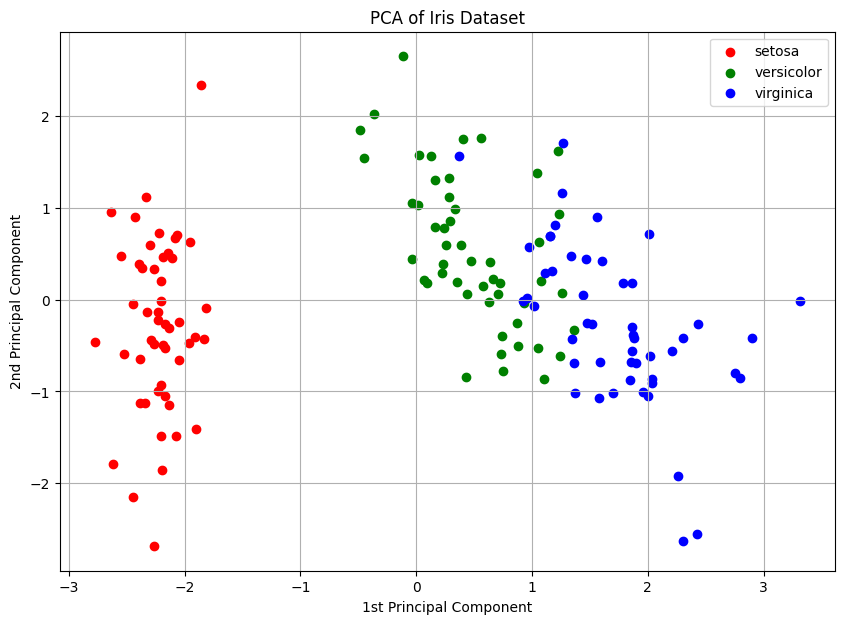

In [18]:
# Visualize the two principal components
plt.figure(figsize=(10, 7))
for target, color, label in zip([0, 1, 2], ['r', 'g', 'b'], iris.target_names):
    plt.scatter(X_pca[y == target, 0], X_pca[y == target, 1], color=color, label=label)
plt.xlabel('1st Principal Component')
plt.ylabel('2nd Principal Component')
plt.title('PCA of Iris Dataset')
plt.legend()
plt.grid(True)
plt.show()

In [30]:
# Calculate the explained variance (the amount of variance captured by each eigenvalue)
explained_variance = sorted_eigenvalues / np.sum(sorted_eigenvalues)

# Cumulative explained variance for the first two components
cumulative_explained_variance = np.sum(explained_variance[:2])

# Print the explained variance for each component
print("\nExplained Variance by Each Component:\n", explained_variance)

# Print the cumulative explained variance for the first two components
print("\nCumulative Explained Variance for the First Two Components: {:.2f}%".format(cumulative_explained_variance * 100))


Explained Variance by Each Component:
 [0.72962445 0.22850762 0.03668922 0.00517871]

Cumulative Explained Variance for the First Two Components: 95.81%
